In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Where should Lawton retire?

In [2]:
income = Table.read_table('data/us-median-income-2023.csv')
income

Geographic Area Name,Median income estimate
Alabama,33108
Alaska,43069
Arizona,39900
Arkansas,32294
California,41901
Colorado,46958
Connecticut,46415
Delaware,41678
District of Columbia,70144
Florida,36270


In [5]:
income = income.take(np.arange(52, income.num_rows))

In [6]:
income

Geographic Area Name,Median income estimate
"Abanda CDP, Alabama",34911
"Abbeville city, Alabama",21678
"Adamsville city, Alabama",31873
"Addison town, Alabama",30833
"Akron town, Alabama",22500
"Alabaster city, Alabama",43502
"Albertville city, Alabama",29150
"Alexander City city, Alabama",27114
"Alexandria CDP, Alabama",41685
"Aliceville city, Alabama",18750


In [7]:
income.where(0, are.containing('Fresno'))

Geographic Area Name,Median income estimate
"Centerville CDP (Fresno County), California",-
"Fresno city, California",33148
"Fresno CDP, Ohio",16488
"Fresno CDP, Texas",42540
"Los Fresnos city, Texas",33168
"Los Fresnos CDP, Texas",45057


In [8]:
income.where(0, are.containing('Clovis'))

Geographic Area Name,Median income estimate
"Clovis city, California",47696
"Clovis city, New Mexico",31392


In [10]:
def fix(x):
    try:
        return int(x)
    except:
        return -1

income = income.with_column('Median income estimate', income.apply(fix, 1))

In [11]:
income.where(0, are.containing('Fresno'))

Geographic Area Name,Median income estimate
"Centerville CDP (Fresno County), California",-1
"Fresno city, California",33148
"Fresno CDP, Ohio",16488
"Fresno CDP, Texas",42540
"Los Fresnos city, Texas",33168
"Los Fresnos CDP, Texas",45057


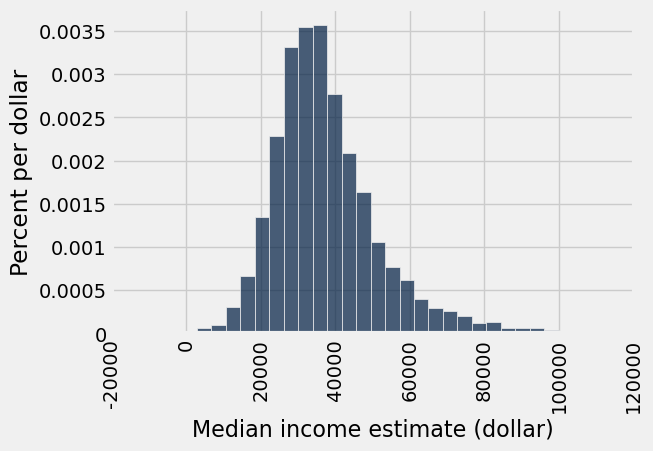

In [15]:
income.where(1, are.between_or_equal_to(0, 100000)).hist(1, bins=25, unit='dollar')

In [16]:
tjs = Table.read_table('data/trader-joes-locations-2025.csv')
tjs

City
"Birmingham, AL"
"Hoover, AL"
"Huntsville, AL"
"Chandler, AZ"
"Gilbert, AZ"
"Glendale, AZ"
"Mesa, AZ"
"Oro Valley, AZ"
"Phoenix, AZ"
"Prescott, AZ"


In [19]:
'Fresno, CA'.split(',')

['Fresno', ' CA']

In [20]:
'Fresno, CA'.split(',')[0]

'Fresno'

In [21]:
'Fresno, CA'.split(',')[1]

' CA'

In [22]:
'Fresno, CA'.split(',')[1].strip()

'CA'

In [28]:
def get_city(s):
    return s.split(',')[0]

def get_state_abbrev(s):
    return s.split(',')[1].strip()

In [27]:
state_abbrevs = Table.read_table('data/state-abbreviations.csv')
state_abbrevs

Name,Abbreviation
Alabama,AL
Alaska,AK
American Samoa,AS
Arizona,AZ
Arkansas,AR
California,CA
Colorado,CO
Connecticut,CT
Delaware,DE
District of Columbia,DC


In [32]:
state_abbrevs.where('Abbreviation', 'CA').row(0).item(0)

'California'

In [33]:
def get_state(s):
    state_abbrev = get_state_abbrev(s)
    return state_abbrevs.where('Abbreviation', state_abbrev).row(0).item(0)

In [34]:
get_city('Fresno, CA')

'Fresno'

In [35]:
get_state_abbrev('Fresno, CA')

'CA'

In [36]:
get_state('Fresno, CA')

'California'

In [37]:
tjs

City
"Birmingham, AL"
"Hoover, AL"
"Huntsville, AL"
"Chandler, AZ"
"Gilbert, AZ"
"Glendale, AZ"
"Mesa, AZ"
"Oro Valley, AZ"
"Phoenix, AZ"
"Prescott, AZ"


In [39]:
tjs = Table().with_columns(
    'City', tjs.apply(get_city, 0),
    'State', tjs.apply(get_state, 0)
)
tjs

City,State
Birmingham,Alabama
Hoover,Alabama
Huntsville,Alabama
Chandler,Arizona
Gilbert,Arizona
Glendale,Arizona
Mesa,Arizona
Oro Valley,Arizona
Phoenix,Arizona
Prescott,Arizona


In [40]:
income

Geographic Area Name,Median income estimate
"Abanda CDP, Alabama",34911
"Abbeville city, Alabama",21678
"Adamsville city, Alabama",31873
"Addison town, Alabama",30833
"Akron town, Alabama",22500
"Alabaster city, Alabama",43502
"Albertville city, Alabama",29150
"Alexander City city, Alabama",27114
"Alexandria CDP, Alabama",41685
"Aliceville city, Alabama",18750


In [41]:
income.where(0, are.containing('Phoenix'))

Geographic Area Name,Median income estimate
"Phoenix city, Arizona",40786
"Phoenix Lake CDP, California",40493
"Phoenix village, Illinois",24000
"Phoenix village, New York",37980
"Phoenix city, Oregon",30893
"Phoenixville borough, Pennsylvania",60073


In [42]:
income.where(0, are.containing('Phoenix')).where(0, are.containing('Arizona'))

Geographic Area Name,Median income estimate
"Phoenix city, Arizona",40786


In [45]:
def get_median_income(city, state):
    results = income.where(0, are.containing(city)).where(0, are.containing(state))
    if results.num_rows > 0:
        return results.column(1).item(0)
    else:
        return -1

In [47]:
tjs_with_income = tjs.with_column('Median Income', tjs.apply(get_median_income, 'City', 'State'))
tjs_with_income

City,State,Median Income
Birmingham,Alabama,28054
Hoover,Alabama,53074
Huntsville,Alabama,38349
Chandler,Arizona,52580
Gilbert,Arizona,55389
Glendale,Arizona,36441
Mesa,Arizona,24573
Oro Valley,Arizona,50816
Phoenix,Arizona,40786
Prescott,Arizona,38235


In [49]:
income.where(0, are.containing('Fresno')).where(0, are.containing('California'))

Geographic Area Name,Median income estimate
"Centerville CDP (Fresno County), California",-1
"Fresno city, California",33148


In [48]:
tjs_with_income.sort('Median Income')

City,State,Median Income
Chatsworth,California,-1
Eagle Rock,California,-1
Encino,California,-1
Fresno,California,-1
Granada Hills,California,-1
Greenbrae,California,-1
La Canada,California,-1
La Jolla,California,-1
Marina Del Rey,California,-1
North Hollywood,California,-1


In [51]:
tjs_with_income.where('Median Income', are.above(0)).sort('Median Income').show(25)

City,State,Median Income
Fairfield,Connecticut,4383
State College,Pennsylvania,10085
East Lansing,Michigan,12408
Newark,Delaware,17087
College Park,Maryland,17695
Williamsburg,Virginia,23543
Mesa,Arizona,24573
Kalamazoo,Michigan,24899
Gainesville,Florida,25603
Corvallis,Oregon,26868


In [52]:
# The first two are "cities" containing only college students

# Mendel

In [55]:
mendel_proportions = make_array(0.75, 0.25)
mendel_proportions_purple = mendel_proportions.item(0)

sample_proportions(929, mendel_proportions)

array([ 0.7459634,  0.2540366])

In [63]:
def one_simulated_distance():
    sample_proportion_purple = sample_proportions(929, mendel_proportions).item(0)
    return abs(sample_proportion_purple - mendel_proportions_purple)

In [65]:
one_simulated_distance()

0.030947255113024763

In [66]:
observed_distance = (705 / 929) - 0.75
observed_distance

0.008880516684607098

In [67]:
repetitions = 1000
distances = make_array()
for i in np.arange(repetitions):
    distances = np.append(distances, one_simulated_distance())

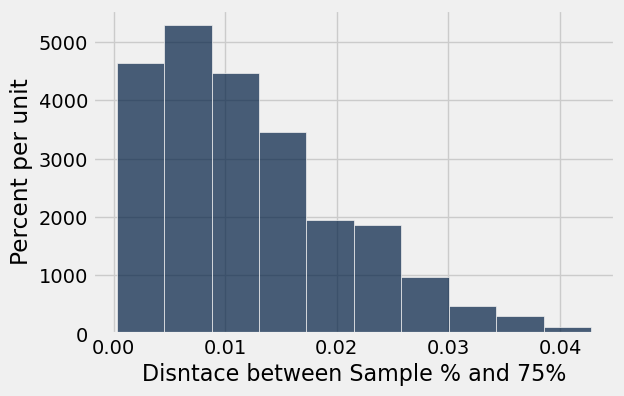

In [69]:
Table().with_column(
    'Disntace between Sample % and 75%', distances
).hist()

In [71]:
np.count_nonzero(distances >= observed_distance) / repetitions

0.578

In [72]:
# Conclusion: we do not reject the null

# Cereal

In [73]:
cereal = Table.read_table('data/cereal.csv')
cereal

name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
100% Bran,N,C,70,4,1,130,10,5,6,280,25,3,1,0.33,68.403
100% Natural Bran,Q,C,120,3,5,15,2,8,8,135,0,3,1,1,33.9837
All-Bran,K,C,70,4,1,260,9,7,5,320,25,3,1,0.33,59.4255
All-Bran with Extra Fiber,K,C,50,4,0,140,14,8,0,330,25,3,1,0.5,93.7049
Almond Delight,R,C,110,2,2,200,1,14,8,-1,25,3,1,0.75,34.3848
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1,0.75,29.5095
Apple Jacks,K,C,110,2,0,125,1,11,14,30,25,2,1,1,33.1741
Basic 4,G,C,130,3,2,210,2,18,8,100,25,3,1.33,0.75,37.0386
Bran Chex,R,C,90,2,1,200,4,15,6,125,25,1,1,0.67,49.1203
Bran Flakes,P,C,90,3,0,210,5,13,5,190,25,3,1,0.67,53.3138


In [76]:
cereal.select('shelf', 'sugars').group('shelf', np.average)

shelf,sugars average
1,4.8
2,9.61905
3,6.52778


In [79]:
cereal.with_column(
    'Shuffled Label', cereal.sample(with_replacement=False).column('shelf')
)

name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating,Shuffled Label
100% Bran,N,C,70,4,1,130,10,5,6,280,25,3,1,0.33,68.403,3
100% Natural Bran,Q,C,120,3,5,15,2,8,8,135,0,3,1,1,33.9837,3
All-Bran,K,C,70,4,1,260,9,7,5,320,25,3,1,0.33,59.4255,2
All-Bran with Extra Fiber,K,C,50,4,0,140,14,8,0,330,25,3,1,0.5,93.7049,3
Almond Delight,R,C,110,2,2,200,1,14,8,-1,25,3,1,0.75,34.3848,3
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1,0.75,29.5095,1
Apple Jacks,K,C,110,2,0,125,1,11,14,30,25,2,1,1,33.1741,1
Basic 4,G,C,130,3,2,210,2,18,8,100,25,3,1.33,0.75,37.0386,2
Bran Chex,R,C,90,2,1,200,4,15,6,125,25,1,1,0.67,49.1203,1
Bran Flakes,P,C,90,3,0,210,5,13,5,190,25,3,1,0.67,53.3138,1


In [82]:
cereal.with_column(
    'Shuffled Label', cereal.sample(with_replacement=False).column('shelf')
).where('Shuffled Label', 2).column('sugars').mean()

5.8571428571428568

In [83]:
def one_sample_average():
    return cereal.with_column(
        'Shuffled Label', cereal.sample(with_replacement=False).column('shelf')
    ).where('Shuffled Label', 2).column('sugars').mean()

simulations = 1000
sample_averages = make_array()
for i in np.arange(simulations):
    sample_averages = np.append(sample_averages, one_sample_average())

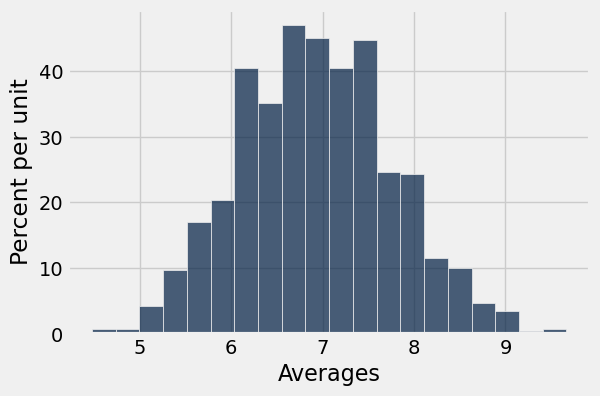

In [86]:
Table().with_column('Averages', sample_averages).hist(0, bins=20)

In [87]:
np.count_nonzero(sample_averages >= 9.61905) / len(sample_averages)

0.001

In [88]:
# Conclusion: we reject the null hypothesis